# Temporal-scale dependence of the drift signal

WienerNet represents nighttime NEE as a Wiener-process SDE,

$$ \mathrm{d}\,\mathrm{NEE} = f\,\mathrm{d}t + \sigma\,\mathrm{d}W,
\qquad f = \frac{\partial R_{eco}}{\partial T}\,\frac{\mathrm{d}T}{\mathrm{d}t}, $$

where the drift $f$ is the analytic temperature derivative of the Lloyd–Taylor
respiration model and $\sigma\,\mathrm{d}W$ is the stochastic (aleatoric) term.

How much of the step-to-step change in NEE can the deterministic drift explain?
Over a single 30-minute step the air temperature changes by only $\sim0.3\,^\circ$C,
so the temperature-driven change in respiration is small and is swamped by turbulent
and instrumental variability. We therefore expect the deterministic (temperature-driven)
fraction of the NEE increment to be negligible at 30 min and to **grow with the
integration horizon**, as temperature accumulates a meaningful change.

This notebook quantifies that scaling by correlating the NEE increment
$\Delta\mathrm{NEE}=\mathrm{NEE}_{t+k}-\mathrm{NEE}_t$ with the temperature increment
$\Delta T_a$ and the Lloyd–Taylor respiration increment $\Delta R_{eco}$ across horizons
from 30 min to 8 h. Only **contiguous** spans are used (the lagged sample is exactly
$k\times30$ min later), so no correlation straddles a data gap or a day boundary.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "wienernet").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from wienernet.evaluation import (
    increment_correlation_by_lag,
    plot_increment_correlation,
    setup_paper_style,
)

setup_paper_style()
OUT_DIR = REPO_ROOT / "notebooks" / "manuscript_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Site final_night parquets (E0, rb, Ta, NEE, DateTime).
SITE_PATHS = {
    "Rosedene":  REPO_ROOT / "data_manipulation/final_night_data.parquet",
    "Redmere 1": REPO_ROOT / "data_manipulation/other_sites/redmere_1/final_night_data.parquet",
    "Redmere 2": REPO_ROOT / "data_manipulation/other_sites/redmere_2/final_night_data.parquet",
    "Great Fen": REPO_ROOT / "data_manipulation/other_sites/great_fen/final_night_data.parquet",
}
site_dfs = {}
for name, p in SITE_PATHS.items():
    if p.exists():
        site_dfs[name] = pd.read_parquet(p)
        print(f"  {name:10s} rows={len(site_dfs[name]):>6,d}")


  Rosedene   rows=59,100
  Redmere 1  rows=14,382
  Redmere 2  rows=21,436
  Great Fen  rows=15,705


## Method

For each site we reconstruct
$R_{eco}(T)=r_b\exp\!\big(E_0(\tfrac{1}{T_{ref}+T_0}-\tfrac{1}{T+T_0})\big)$ from the
fitted $(E_0,r_b)$ (Reichstein convention, $T_0=46.02\,^\circ$C), and at each lag $k$
take the Pearson correlation between $\Delta\mathrm{NEE}$ and $\Delta R_{eco}$
(and $\Delta T_a$) over all contiguous $k$-step pairs. The **pooled** estimate
concatenates all sites.


In [2]:
LAGS = (1, 2, 4, 6, 8, 12, 16)   # 0.5 h ... 8 h at 30-min steps
res = increment_correlation_by_lag(site_dfs, lags=LAGS)

pooled = res[res.site == "pooled"][["hours", "n", "corr_dTa", "corr_dReco"]].round(3)
print("Pooled correlation of the NEE increment with temperature / Reco increment:")
print(pooled.to_string(index=False))


Pooled correlation of the NEE increment with temperature / Reco increment:
 hours     n  corr_dTa  corr_dReco
   0.5 53614     0.015       0.014
   1.0 49863     0.032       0.038
   2.0 43581     0.059       0.082
   3.0 38052     0.084       0.123
   4.0 32953     0.098       0.148
   6.0 23603     0.138       0.218
   8.0 15199     0.143       0.235


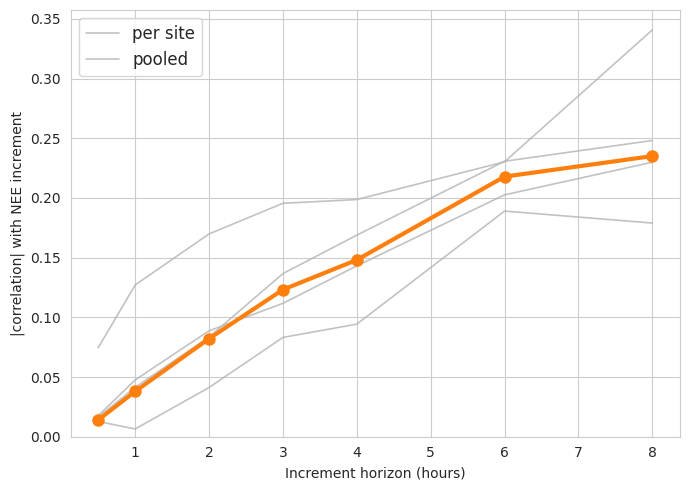

In [3]:
fig = plot_increment_correlation(
    res, metric="corr_dReco",
    save_path=OUT_DIR / "07_increment_corr_vs_timescale.png",
)
plt.show()


## Results

The correlation between the NEE increment and the Lloyd–Taylor respiration increment
**rises monotonically with the horizon** — from near-zero at 30 min ($|r|\approx0.02$)
to $|r|\approx0.25$ at 8 h — and the physics increment $\Delta R_{eco}$ tracks the NEE
increment slightly better than raw $\Delta T_a$ at the longer horizons, as expected from
the nonlinear temperature response. The per-site curves (grey) share the same rising
shape, so the effect is not driven by any single site. The flattening beyond $\sim8$ h
is a sampling limit: nights rarely provide contiguous spans longer than that.


## Implications for the SDE

This confirms that the physics drift is a **longer-timescale** signal. At the native
30-min step it is near-inert and the increment is diffusion-dominated; over multiple
hours the temperature-driven respiration change becomes the dominant *deterministic*
component. Two consequences for the model:

1. **Multi-scale increment supervision.** Constrain the drift at the horizons where the
   temperature response is identifiable (1–8 h) rather than forcing it to fit 30-min
   noise; the diffusion term then absorbs the short-scale variability.
2. **Rollout evaluation.** The drift's contribution is cumulative, so it should be
   assessed by integrating the SDE over hours and comparing the trajectory to the
   temperature-driven $R_{eco}(T)$ trend — not by one-step increment metrics.

The deterministic fraction remains **modest even at 8 h** ($|r|\approx0.25$, $\sim6\%$
of variance): NEE increments are dominated by non-temperature variability at every
resolution we can test; the physics fraction grows with horizon but does not dominate.
The physics is strong at the **level** ($\mathrm{NEE}\approx R_{eco}(T)$, the partitioning
premise) and weak at the short-scale **increment** — the tension any 30-min SDE must
accommodate.
